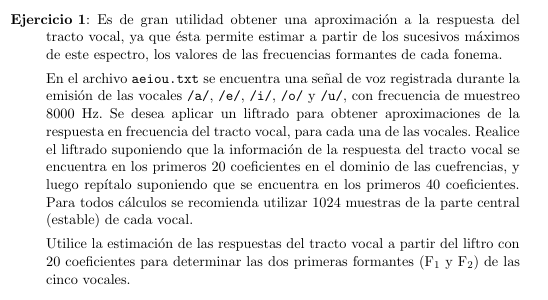

In [116]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq, ifft, fftshift
import csv

In [117]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

salida = cargar_dataset("PDS_Datos_TP2/aeiou_mas.txt")
salida /= max(salida)
#idx = np.arange(0, salida.shape[0], 5)
#salida = salida[idx]
N = len(salida)
#salida -= np.mean(salida)
print(salida.shape)

(36000,)


In [118]:
from scipy.io.wavfile import write

# cargar los datos (una columna de números)
#data = np.loadtxt("PDS_TP1_signals/hello.txt")

# normalizar si hace falta (ejemplo para float)
data = salida
data = data / np.max(np.abs(data))

# convertir a 16 bits
data_int16 = np.int16(data * 32767)

# guardar como WAV (ej: 44100 Hz)
write("PDS_Datos_TP2/audio_aeiou_mas.wav", 8000, data_int16)


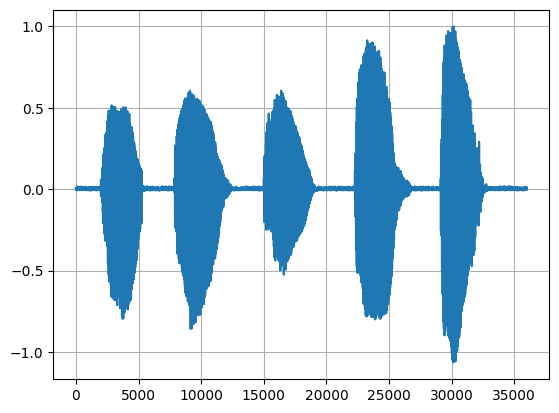

In [119]:
plt.plot(salida)
plt.grid()

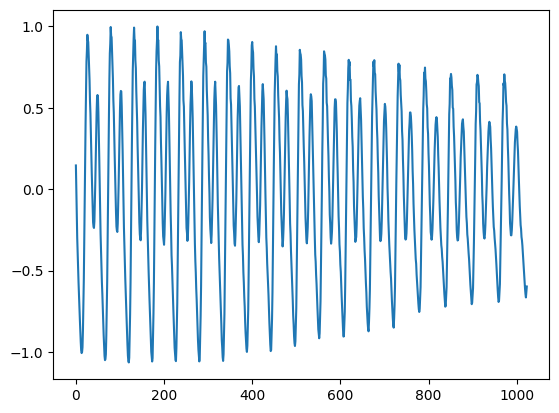

In [120]:
a = salida[2800 : 2800+1024]
e = salida[8500 : 9524]
i = salida[16000 : 17024]
o = salida[23500 : 24524]
u = salida[30000 : 31024]
plt.plot(u)

In [121]:
def extraer_coeficientes_cepstrales(vocal):
    v_tranf = fft(vocal)
    v_real = np.real(v_tranf)
    v_im = np.imag(v_tranf)
    v_norm = np.sqrt(v_real**2 + v_im**2)
    v_tranf = np.log(v_norm)
    v_inv = ifft(v_tranf)
    return np.array(v_inv)

1024


C:\Users\mateo\AppData\Local\Temp\ipykernel_15136\467894632.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  filtrado[: umbral] = coeficientes[: umbral]
C:\Users\mateo\AppData\Local\Temp\ipykernel_15136\467894632.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  filtrado[-umbral :] = coeficientes[-umbral :]
c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\numpy\ma\core.py:3452: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
c:\Users\mateo\Desktop\facultad\IIA\4° año\PDS\Codigos\venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<StemContainer object of 3 artists>

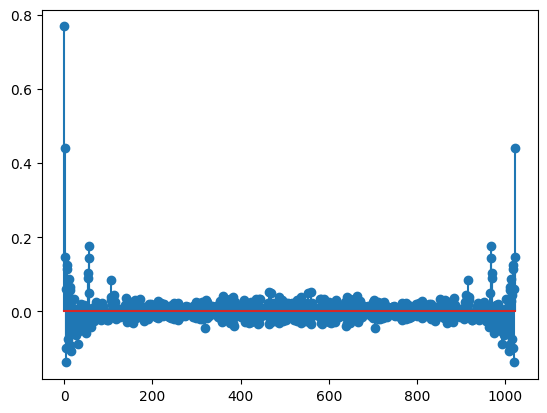

In [122]:
vocales = [a,e,i,o,u]
coef = []
coef_filtrado = []
umbral = 20

print(len(vocales[2]))
for pelotudo in range(len(vocales)):
    datos = np.array(vocales[pelotudo])
    coeficientes = extraer_coeficientes_cepstrales(vocales[pelotudo])
    coef.append(coeficientes)
    filtrado = np.zeros_like(a)
    filtrado[: umbral] = coeficientes[: umbral] 
    filtrado[-umbral :] = coeficientes[-umbral :]
    coef_filtrado.append(filtrado)

coef = np.array(coef)
coef_filtrado = np.array(coef_filtrado)
plt.stem(coef[0])


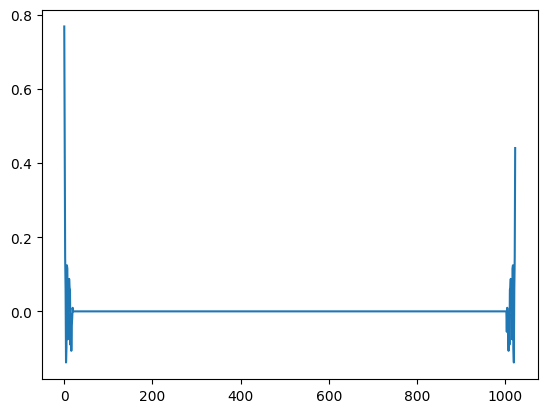

In [123]:
plt.plot(coef_filtrado[0])

In [124]:
def señal_desde_coefs(coeficientes):
    fft_coef = fft(coeficientes)
    fft_real = np.real(fft_coef)
    fft_exp = np.exp(fft_real)
    fft_exp /= len(fft_exp)
    return np.array(fft_exp)

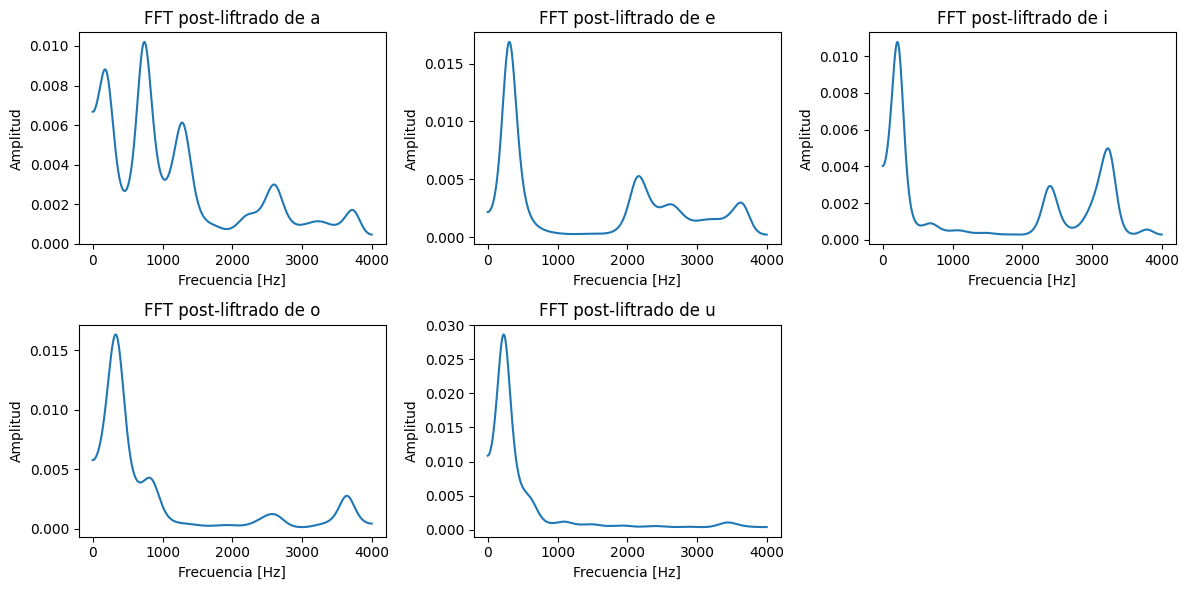

In [132]:
letras = ["a", "e", "i", "o", "u"]
ffts_post_liftrado = []

frecs = fftfreq(1024, d=1/8000)  # eje de frecuencias
frecs = frecs[: len(frecs)//2]

plt.figure(figsize=(12,6))
for j in range(coef_filtrado.shape[0]):
    plt.subplot(2,3,j+1)
    frecu = señal_desde_coefs(coef_filtrado[j])
    ffts_post_liftrado.append(frecu)

    plt.title(f"FFT post-liftrado de {letras[j]}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Amplitud")
    plt.tight_layout()
    plt.plot(frecs,frecu[:len(frecu)//2])

plt.show()

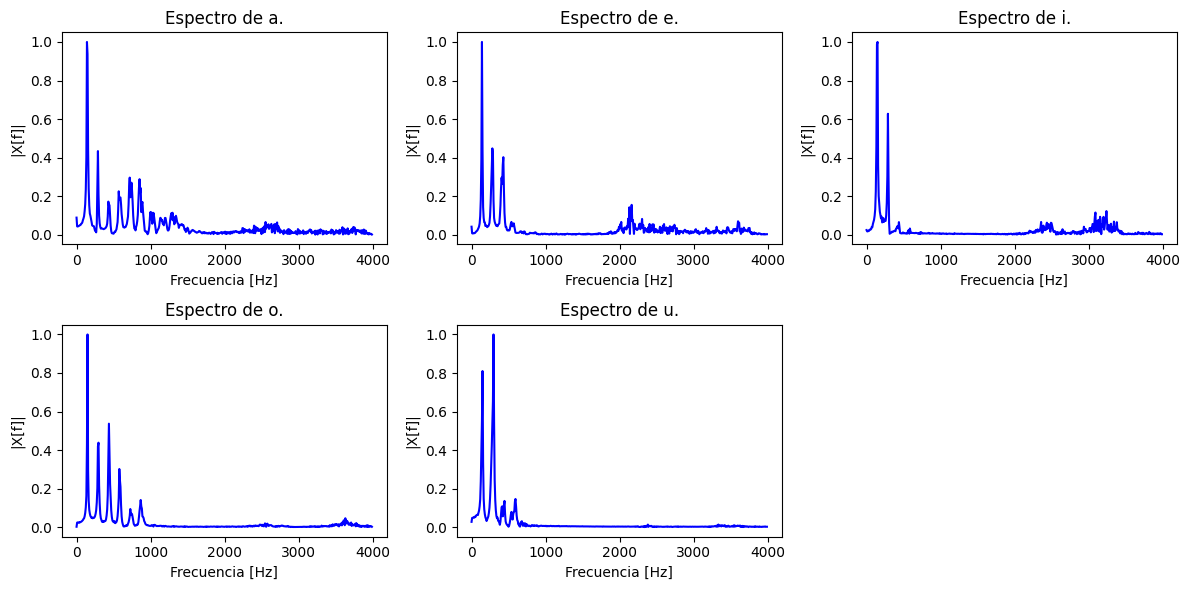

In [131]:

plt.figure(figsize=(12,6))
for j in range(len(vocales)):
    S = fft(vocales[j])
    # OBTENIENDO EL ESPECTRO DE LA SEÑAL
    S /= len(S)

    # Frecs
    S_real = np.real(S)
    S_im = np.imag(S)
    S_norm = np.sqrt(S_real**2 + S_im**2)
    S_norm = fftshift(S)

    frecs = fftfreq(1024, d=1/frecM)  # eje de frecuencias
    frecs = fftshift(frecs)        # ordenar el eje: negativos a la izquierda

    y_xd = np.abs(S_norm)/max(np.abs(S_norm))
    # dominio de frecuencias
    plt.subplot(2,3,j+1)

    plt.plot(frecs[len(frecs)//2 :], y_xd[len(frecs)//2:], label="DFT de la señal", color="blue")
    plt.title(f"Espectro de {letras[j]}.")
    plt.tight_layout()
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|X[f]|")

plt.show()

In [141]:
def obtener_picos(senial, cant_intervalos = 101):
    # La idea es laburar en cant_intervalos intervalos de
    # igual tamaño, calcular su energía y comparar con la
    # del siguiente intervalo. Si es mucho menor, hay un pico.
    intervalos = np.linspace(0, len(senial), cant_intervalos)

    print(intervalos)

obtener_picos(ffts_post_liftrado[0])

[   0.     10.24   20.48   30.72   40.96   51.2    61.44   71.68   81.92
   92.16  102.4   112.64  122.88  133.12  143.36  153.6   163.84  174.08
  184.32  194.56  204.8   215.04  225.28  235.52  245.76  256.    266.24
  276.48  286.72  296.96  307.2   317.44  327.68  337.92  348.16  358.4
  368.64  378.88  389.12  399.36  409.6   419.84  430.08  440.32  450.56
  460.8   471.04  481.28  491.52  501.76  512.    522.24  532.48  542.72
  552.96  563.2   573.44  583.68  593.92  604.16  614.4   624.64  634.88
  645.12  655.36  665.6   675.84  686.08  696.32  706.56  716.8   727.04
  737.28  747.52  757.76  768.    778.24  788.48  798.72  808.96  819.2
  829.44  839.68  849.92  860.16  870.4   880.64  890.88  901.12  911.36
  921.6   931.84  942.08  952.32  962.56  972.8   983.04  993.28 1003.52
 1013.76 1024.  ]
